In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

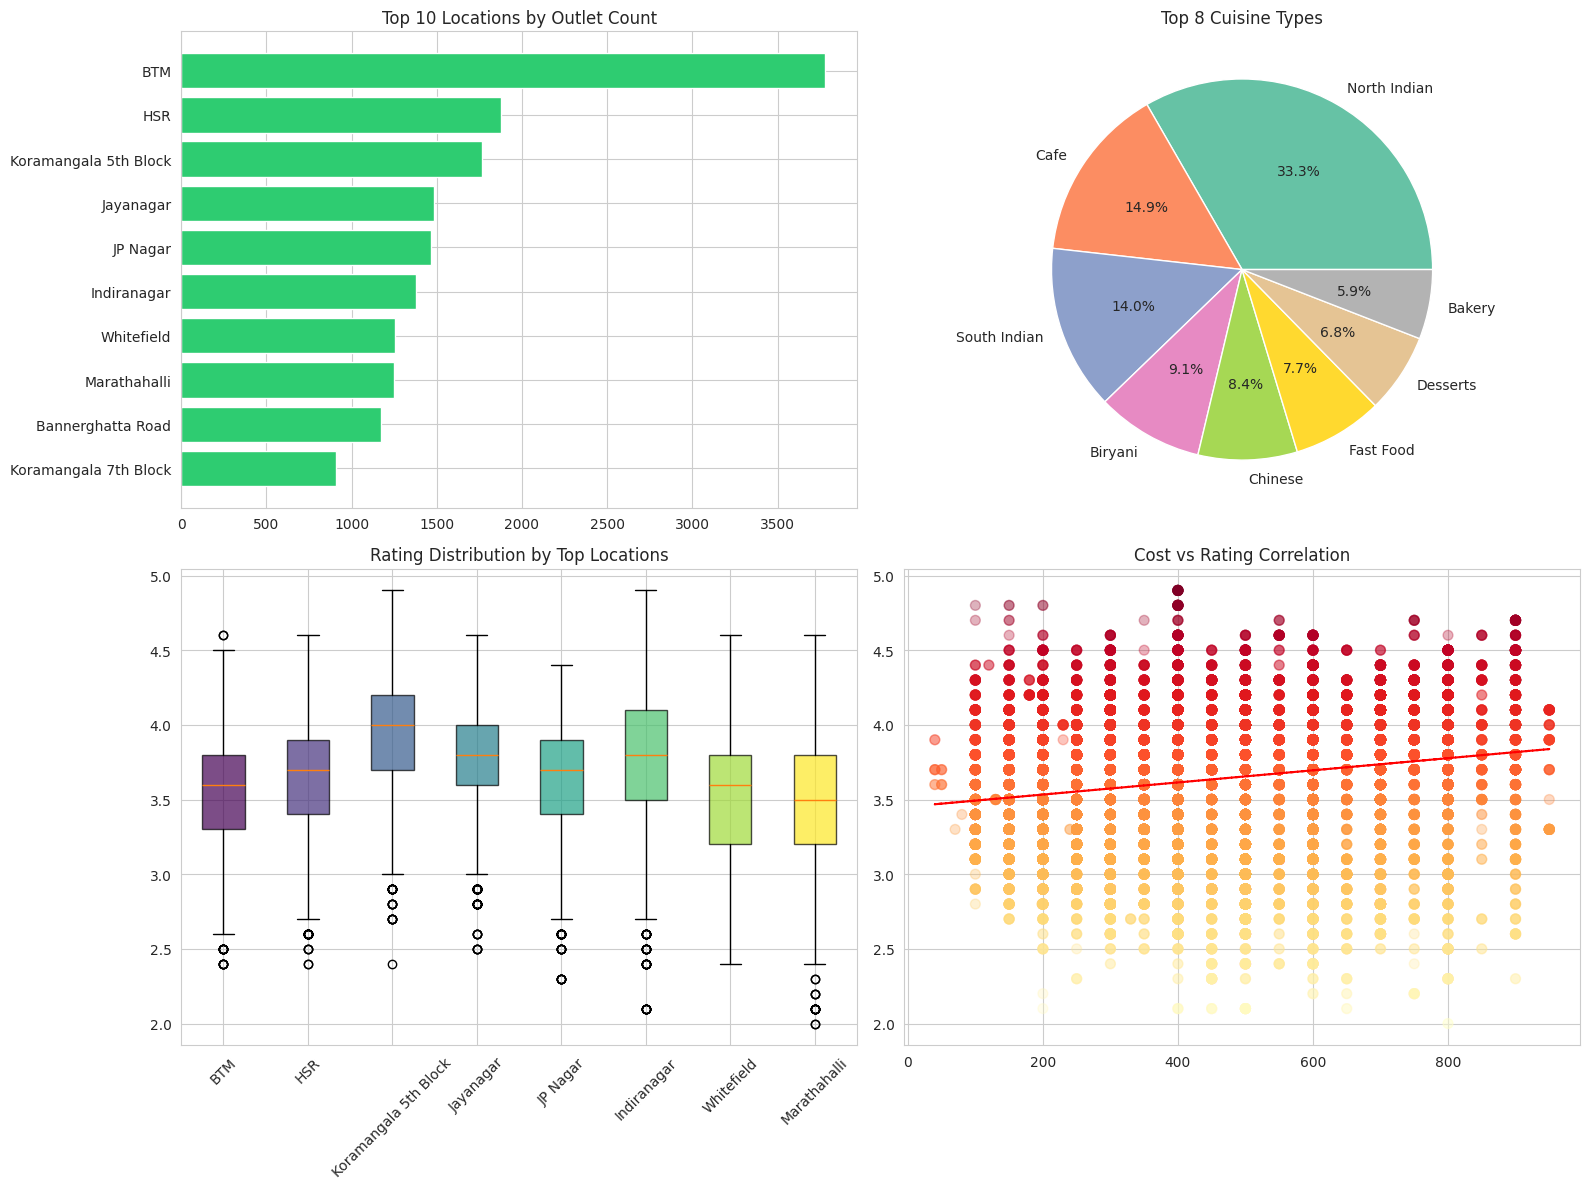

ANALYSIS REPORT
----------------
Dataset Size: 34709 rows
Top Location: BTM (3778 outlets)
Average Rating: 3.63
Top Cuisine: North Indian
Best Rated Area: Sankey Road (4.00)
Cost-Rating Correlation: 0.195

CONCLUSION:
Market saturation is highest in BTM. 
Ratings cluster around 3.63, indicating limited differentiation.
Correlation between price and quality is present.



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import glob
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Download Correct Dataset (Zomato Bangalore)
print("Downloading Zomato Bangalore dataset...")
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")
csv_files = glob.glob(os.path.join(path, "**/*.csv"), recursive=True)

if not csv_files:
    raise Exception("Dataset files not found.")

file_path = csv_files[0]
df = pd.read_csv(file_path, encoding='latin-1')

# 2. Column Mapping

df.rename(columns={'approx_cost(for two people)': 'cost_for_two'}, inplace=True)

drop_cols = ['url', 'address', 'phone', 'menu_item', 'dish_liked', 'reviews_list']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

# Clean Rate
df['rate'] = df['rate'].astype(str).apply(lambda x: x.split('/')[0] if '/' in str(x) else x)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean Cost
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

# Drop missing critical data
df.dropna(subset=['rate', 'cost_for_two', 'cuisines'], inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# 3. Feature Engineering
df['Location'] = df['location'].str.strip()
df['Primary_Cuisine'] = df['cuisines'].apply(lambda x: str(x).split(',')[0].strip())

# 4. Analysis Metrics
loc_counts = df['Location'].value_counts().head(10)
avg_rating = df['rate'].mean()
top_cuisine = df['Primary_Cuisine'].value_counts().index[0]
best_loc = df.groupby('Location')['rate'].mean().sort_values(ascending=False).head(1)
corr = df['cost_for_two'].corr(df['rate'])

# 5. Visualization Generation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Top Locations
axes[0, 0].barh(loc_counts.index, loc_counts.values, color='#2ecc71')
axes[0, 0].set_title('Top 10 Locations by Outlet Count')
axes[0, 0].invert_yaxis()

# Chart 2: Cuisine Distribution
top_cuis = df['Primary_Cuisine'].value_counts().head(8)
colors = plt.cm.Set2(np.linspace(0, 1, len(top_cuis)))
axes[0, 1].pie(top_cuis.values, labels=top_cuis.index, autopct='%1.1f%%', colors=colors)
axes[0, 1].set_title('Top 8 Cuisine Types')

# Chart 3: Rating Box Plot
top_loc_names = df['Location'].value_counts().head(8).index
plot_data = df[df['Location'].isin(top_loc_names)]
bp = axes[1, 0].boxplot([plot_data[plot_data['Location']==l]['rate'].dropna() for l in top_loc_names],
                        labels=top_loc_names, patch_artist=True)
for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, len(top_loc_names)))):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_title('Rating Distribution by Top Locations')

# Chart 4: Cost vs Rating
valid = df[['cost_for_two', 'rate']].dropna()
axes[1, 1].scatter(valid['cost_for_two'], valid['rate'], alpha=0.3, c=valid['rate'], cmap='YlOrRd', s=50)
z = np.polyfit(valid['cost_for_two'], valid['rate'], 1)
p = np.poly1d(z)
axes[1, 1].plot(valid['cost_for_two'], p(valid['cost_for_two']), "r--")
axes[1, 1].set_title('Cost vs Rating Correlation')

plt.tight_layout()
plt.savefig('restaurant_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


report = f"""ANALYSIS REPORT
----------------
Dataset Size: {len(df)} rows
Top Location: {loc_counts.index[0]} ({loc_counts.iloc[0]} outlets)
Average Rating: {avg_rating:.2f}
Top Cuisine: {top_cuisine}
Best Rated Area: {best_loc.index[0]} ({best_loc.values[0]:.2f})
Cost-Rating Correlation: {corr:.3f}

CONCLUSION:
Market saturation is highest in {loc_counts.index[0]}. 
Ratings cluster around {avg_rating:.2f}, indicating limited differentiation.
Correlation between price and quality is {'negligible' if abs(corr) < 0.1 else 'present'}.
"""

print(report)

with open('analysis_conclusion.txt', 'w') as f:
    f.write(report)